<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br><br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br><br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>

# Padronização, Higienização e Caracterização de Dados

Neste notebook, os **Palmer Penguins** serão usados para mostrar um fluxo simples de preparação de dados: diagnóstico, tratamento de ausências, codificação, identificação de valores extremos, transformação de escala e análise de relações entre variáveis.

Um segundo exemplo, com partidas de **Copa do Mundo**, mostra como combinar tabelas sem multiplicar registros.

**Fontes:** snapshots fixos e públicos dos projetos [Palmer Penguins](https://github.com/allisonhorst/palmerpenguins/tree/8957207b78d6ccd1b4654a9dd9c9041b657478ab) e [International Football Results](https://github.com/martj42/international_results/tree/394fe81893b062fbc2cf6257e988ac7cc4c039a1), ambos disponibilizados em domínio público (CC0).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, RobustScaler, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4.5), "figure.dpi": 110})

## Dados principais: Palmer Penguins

Cada linha representa um pinguim observado no arquipélago Palmer, na Antártica.

| Coluna | Significado | Tipo |
|---|---|---|
| `especie` | Espécie do pinguim: Adelie, Chinstrap ou Gentoo | Categórica nominal |
| `ilha` | Ilha onde o animal foi observado | Categórica nominal |
| `comprimento_bico_mm` | Comprimento do bico, em milímetros | Numérica contínua |
| `profundidade_bico_mm` | Profundidade do bico, em milímetros | Numérica contínua |
| `comprimento_nadadeira_mm` | Comprimento da nadadeira, em milímetros | Numérica contínua |
| `massa_corporal_g` | Massa corporal, em gramas; será o alvo do exemplo de preparação | Numérica contínua |
| `sexo` | Sexo registrado do animal | Categórica nominal |
| `ano` | Ano da observação | Numérica discreta |

In [ ]:
URL_PINGUINS = (
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/"
    "8957207b78d6ccd1b4654a9dd9c9041b657478ab/inst/extdata/penguins.csv"
)

# Lê o arquivo e troca os nomes das colunas logo no início.
pinguins = pd.read_csv(URL_PINGUINS).rename(columns={
    "species": "especie",
    "island": "ilha",
    "bill_length_mm": "comprimento_bico_mm",
    "bill_depth_mm": "profundidade_bico_mm",
    "flipper_length_mm": "comprimento_nadadeira_mm",
    "body_mass_g": "massa_corporal_g",
    "sex": "sexo",
    "year": "ano",
})

In [ ]:
pinguins.head()

,especie,ilha,comprimento_bico_mm,profundidade_bico_mm,comprimento_nadadeira_mm,massa_corporal_g,sexo,ano
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 1. Diagnóstico inicial

Antes de transformar os dados, verificamos o tipo das colunas, a quantidade de categorias e os valores ausentes. Esse diagnóstico orienta o tratamento adequado para cada variável.

In [ ]:
diagnostico = pd.DataFrame({
    "tipo": pinguins.dtypes.astype(str),
    "valores_unicos": pinguins.nunique(),
    "ausentes": pinguins.isna().sum(),
})

diagnostico

,tipo,valores_unicos,ausentes
especie,object,3,0
ilha,object,3,0
comprimento_bico_mm,float64,164,2
profundidade_bico_mm,float64,80,2
comprimento_nadadeira_mm,float64,55,2
massa_corporal_g,float64,94,2
sexo,object,2,11
ano,int64,3,0


In [ ]:
pinguins[pinguins['comprimento_nadadeira_mm'].isna()]

,especie,ilha,comprimento_bico_mm,profundidade_bico_mm,comprimento_nadadeira_mm,massa_corporal_g,sexo,ano
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


In [ ]:
pinguins.loc[3, 'massa_corporal_g'] = 3750.0
pinguins.loc[271, 'massa_corporal_g'] = 3750.0

## 2. Valores ausentes e separação dos dados

Um alvo ausente não permite avaliar a previsão; por isso, as duas linhas sem `massa_corporal_g` serão removidas **antes** da divisão. Já uma feature ausente pode ser preenchida por uma regra aprendida somente no treino.

Neste arquivo, as duas linhas sem medidas numéricas também não possuem o alvo. Após removê-las, restam ausências apenas em `sexo`. Ainda manteremos a imputação numérica pela mediana no fluxo final, pois novos dados podem apresentar esse problema.

In [ ]:
# Remove apenas as linhas em que o alvo não foi registrado.
dados_modelo = pinguins.dropna(subset=["massa_corporal_g"]).copy()

X = dados_modelo.drop(columns="massa_corporal_g")
y = dados_modelo["massa_corporal_g"]

# A separação ocorre antes do ajuste dos transformadores.
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [ ]:
resumo_divisao = pd.Series({
    "linhas originais": len(pinguins),
    "linhas duplicadas no arquivo": pinguins.duplicated().sum(),
    "alvos ausentes removidos": pinguins["massa_corporal_g"].isna().sum(),
    "linhas de treino": len(X_treino),
    "linhas de teste": len(X_teste),
    "índices presentes nos dois conjuntos": len(X_treino.index.intersection(X_teste.index)),
})

resumo_divisao.to_frame("quantidade")

,quantidade
linhas originais,344
linhas duplicadas no arquivo,0
alvos ausentes removidos,0
linhas de treino,275
linhas de teste,69
índices presentes nos dois conjuntos,0


### Imputação numérica

A **mediana** é adequada quando queremos reduzir a influência de valores extremos. O valor usado deve ser calculado no treino e apenas aplicado ao teste; usar todo o conjunto anteciparia informação do teste.

In [ ]:
features_numericas = [
    "comprimento_bico_mm",
    "profundidade_bico_mm",
    "comprimento_nadadeira_mm",
]

imputador_numerico = SimpleImputer(strategy="median")
numericas_treino = imputador_numerico.fit_transform(X_treino[features_numericas])

resumo_imputacao = pd.DataFrame({
    "ausentes_antes": X_treino[features_numericas].isna().sum(),
    "mediana_aprendida": imputador_numerico.statistics_,
    "ausentes_depois": pd.DataFrame(numericas_treino).isna().sum().to_numpy(),
})

resumo_imputacao

,ausentes_antes,mediana_aprendida,ausentes_depois
comprimento_bico_mm,1,44.5,0
profundidade_bico_mm,1,17.3,0
comprimento_nadadeira_mm,1,197.0,0


Nenhuma medida numérica do treino precisava ser preenchida neste recorte. Mesmo assim, as medianas foram aprendidas e deixam o processo preparado para receber novas linhas com ausências.

Imputação não recupera o valor verdadeiro: ela preserva a linha e introduz uma estimativa, que deve ser documentada.

In [ ]:
features_categoricas = ["especie", "ilha", "sexo"]

# Cria uma categoria explícita para valores sem registro.
imputador_categorico = SimpleImputer(
    strategy="constant", fill_value="não informado"
)
categoricas_treino = imputador_categorico.fit_transform(
    X_treino[features_categoricas]
)

# Cria uma coluna binária para cada categoria observada no treino.
codificador = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
categoricas_codificadas = codificador.fit_transform(categoricas_treino)

pd.DataFrame(
    categoricas_codificadas,
    columns=codificador.get_feature_names_out(features_categoricas),
    index=X_treino.index,
).head()

,especie_Adelie,especie_Chinstrap,especie_Gentoo,ilha_Biscoe,ilha_Dream,ilha_Torgersen,sexo_female,sexo_male,sexo_não informado
66,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
229,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
7,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
140,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
323,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
X_treino['especie']

,especie
66,Adelie
229,Gentoo
7,Adelie
140,Adelie
323,Chinstrap
...,...
188,Gentoo
71,Adelie
106,Adelie
270,Gentoo


O **One-Hot Encoding** representa categorias nominais sem criar uma ordem artificial. `handle_unknown="ignore"` permite transformar o teste mesmo que apareça uma categoria não observada no treino.

| Codificação | Quando usar | Decisão neste notebook |
|---|---|---|
| `OneHotEncoder` | Categorias sem ordem, como espécie, ilha e sexo | Aplicado |
| `OrdinalEncoder` | Categorias com ordem conhecida, como baixo < médio < alto | Não aplicado: nenhuma feature possui ordem natural |

Tratar uma variável nominal como ordinal criaria distâncias numéricas que não existem no fenômeno.

## 3. Combinação de tabelas (`merge`)

O exemplo usa partidas de Copa do Mundo até 2022. Cada linha de `partidas` representa um jogo; cada linha de `penaltis` representa uma disputa decidida nos pênaltis.

**Colunas de partidas**

| Coluna | Significado |
|---|---|
| `data` | Data da partida |
| `mandante` | Seleção registrada como mandante |
| `visitante` | Seleção registrada como visitante |
| `gols_mandante` | Gols do mandante antes da disputa de pênaltis |
| `gols_visitante` | Gols do visitante antes da disputa de pênaltis |
| `competicao` | Competição da partida |

**Colunas de disputas de pênaltis**

| Coluna | Significado |
|---|---|
| `data` | Data da partida |
| `mandante` | Seleção registrada como mandante |
| `visitante` | Seleção registrada como visitante |
| `vencedor_penaltis` | Seleção vencedora da disputa |
| `primeiro_cobrador` | Seleção que realizou a primeira cobrança |
| `_merge` | Origem da linha após a junção: `both`, `left_only` ou `right_only` |

| Tipo de junção | Linhas preservadas |
|---|---|
| `inner` | Somente chaves presentes nas duas tabelas |
| `left` | Todas as linhas da tabela à esquerda |
| `outer` | Todas as chaves das duas tabelas |

In [ ]:
BASE_FUTEBOL = (
    "https://raw.githubusercontent.com/martj42/international_results/"
    "394fe81893b062fbc2cf6257e988ac7cc4c039a1"
)

# Lê somente as colunas necessárias e as renomeia.
partidas = pd.read_csv(
    f"{BASE_FUTEBOL}/results.csv",
    usecols=["date", "home_team", "away_team", "home_score", "away_score", "tournament"],
    parse_dates=["date"],
).rename(columns={
    "date": "data",
    "home_team": "mandante",
    "away_team": "visitante",
    "home_score": "gols_mandante",
    "away_score": "gols_visitante",
    "tournament": "competicao",
})

penaltis = pd.read_csv(
    f"{BASE_FUTEBOL}/shootouts.csv",
    usecols=["date", "home_team", "away_team", "winner", "first_shooter"],
    parse_dates=["date"],
).rename(columns={
    "date": "data",
    "home_team": "mandante",
    "away_team": "visitante",
    "winner": "vencedor_penaltis",
    "first_shooter": "primeiro_cobrador",
})

partidas_copa = partidas.loc[
    (partidas["competicao"] == "FIFA World Cup")
    & (partidas["data"].dt.year <= 2022)
].copy()

In [ ]:
chaves = ["data", "mandante", "visitante"]

validacao_chaves = pd.DataFrame({
    "tabela": ["partidas da Copa", "disputas de pênaltis"],
    "linhas": [len(partidas_copa), len(penaltis)],
    "chaves_duplicadas": [
        partidas_copa.duplicated(chaves).sum(),
        penaltis.duplicated(chaves).sum(),
    ],
})

validacao_chaves

,tabela,linhas,chaves_duplicadas
0,partidas da Copa,964,0
1,disputas de pênaltis,683,0


In [ ]:
# O left merge preserva todas as partidas da Copa.
partidas_com_penaltis = partidas_copa.merge(
    penaltis,
    on=chaves,
    how="left",
    validate="one_to_one",
    indicator=True,
)

In [ ]:
resumo_merge = pd.Series({
    "partidas antes do merge": len(partidas_copa),
    "partidas depois do merge": len(partidas_com_penaltis),
    "partidas com disputa de pênaltis": partidas_com_penaltis["vencedor_penaltis"].notna().sum(),
    "chaves encontradas nas duas tabelas": (partidas_com_penaltis["_merge"] == "both").sum(),
    "chaves apenas na tabela de partidas": (partidas_com_penaltis["_merge"] == "left_only").sum(),
})

resumo_merge.to_frame("quantidade")

,quantidade
partidas antes do merge,964
partidas depois do merge,964
partidas com disputa de pênaltis,35
chaves encontradas nas duas tabelas,35
chaves apenas na tabela de partidas,929


As 964 partidas foram preservadas e 35 receberam informações de disputa de pênaltis. Nas outras 929 linhas, `vencedor_penaltis` ausente significa **“não houve disputa”**, e não um erro a ser imputado.

A chave combina data, mandante e visitante porque cada seleção aparece muitas vezes. `validate="one_to_one"` interromperia o merge caso alguma chave estivesse repetida e pudesse multiplicar linhas.

## 4. Identificação de valores extremos

Valores extremos podem ser observações raras, registros influentes ou erros. IIQ e z-score são **sinalizadores**; a decisão final depende do contexto.

- **Regra do IIQ:** sinaliza valores abaixo de $Q_1 - 1{,}5\,IIQ$ ou acima de $Q_3 + 1{,}5\,IIQ$, com $IIQ = Q_3-Q_1$. É robusta porque usa quartis.
- **z-score:** $z=(x-\bar{x})/s$. Um limite comum é $|z|>3$. É mais apropriado para variáveis aproximadamente simétricas e é sensível à média e ao desvio-padrão.

A comparação será feita no comprimento da nadadeira dos pinguins Adelie do treino.

In [ ]:
nadadeira_adelie = X_treino.loc[
    X_treino["especie"] == "Adelie", "comprimento_nadadeira_mm"
].dropna()

q1, q3 = nadadeira_adelie.quantile([0.25, 0.75])
iiq = q3 - q1
limite_iiq_inferior = q1 - 1.5 * iiq
limite_iiq_superior = q3 + 1.5 * iiq

media_adelie = nadadeira_adelie.mean()
desvio_adelie = nadadeira_adelie.std(ddof=1)
limite_z_inferior = media_adelie - 3 * desvio_adelie
limite_z_superior = media_adelie + 3 * desvio_adelie
z_scores = stats.zscore(nadadeira_adelie, ddof=1)

resumo_extremos = pd.DataFrame({
    "metodo": ["IIQ", "z-score"],
    "limite_inferior_mm": [limite_iiq_inferior, limite_z_inferior],
    "limite_superior_mm": [limite_iiq_superior, limite_z_superior],
    "valores_sinalizados": [
        ((nadadeira_adelie < limite_iiq_inferior) | (nadadeira_adelie > limite_iiq_superior)).sum(),
        (abs(z_scores) > 3).sum(),
    ],
})

resumo_extremos.round(2)

,metodo,limite_inferior_mm,limite_superior_mm,valores_sinalizados
0,IIQ,171.50,207.50,2
1,z-score,169.28,209.69,1


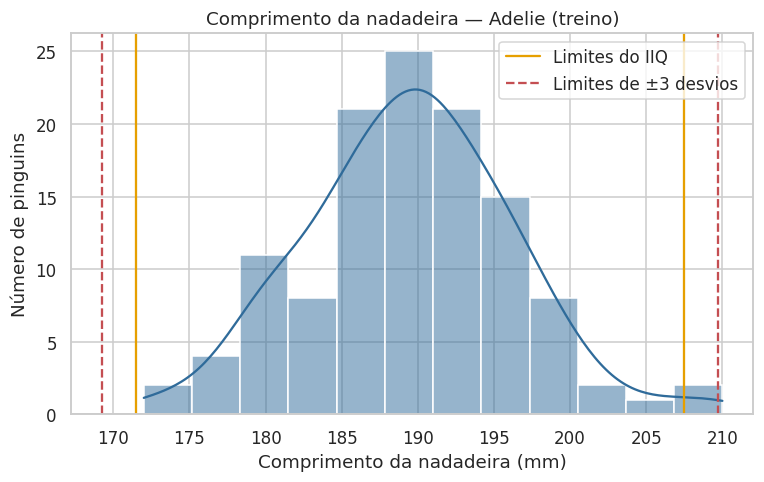

In [ ]:
fig, ax = plt.subplots()
sns.histplot(nadadeira_adelie, bins=12, kde=True, color="#2F6B9A", ax=ax)
ax.axvline(limite_iiq_inferior, color="#E69F00", label="Limites do IIQ")
ax.axvline(limite_iiq_superior, color="#E69F00")
ax.axvline(limite_z_inferior, color="#C44E52", linestyle="--", label="Limites de ±3 desvios")
ax.axvline(limite_z_superior, color="#C44E52", linestyle="--")
ax.set(
    title="Comprimento da nadadeira — Adelie (treino)",
    xlabel="Comprimento da nadadeira (mm)",
    ylabel="Número de pinguins",
)
ax.legend()
plt.show()

*Figura — Distribuição do comprimento da nadadeira dos Adelie. As linhas laranja mostram os limites do IIQ; as vermelhas tracejadas mostram média ± 3 desvios-padrão. Os métodos sinalizam quantidades diferentes porque usam referências distintas. Nenhum ponto deve ser removido sem investigar sua origem.*

## 5. Normalização e padronização

Transformar a escala ajuda métodos sensíveis à distância ou à magnitude das features. Os parâmetros devem ser aprendidos no treino.

| Transformador | Fórmula ou referência | Escala resultante | Cuidado |
|---|---|---|---|
| `MinMaxScaler` | $(x-\min)/(\max-\min)$ | Geralmente entre 0 e 1 no treino | Sensível aos extremos |
| `StandardScaler` | $(x-\bar{x})/s$ | Média 0 e desvio próximo de 1 no treino | Usa média e desvio-padrão |
| `RobustScaler` | $(x-\text{mediana})/IIQ$ | Mediana 0; escala baseada no IIQ | Mais resistente a extremos |

Essas transformações não removem extremos e não tornam a distribuição Normal.

In [ ]:
nadadeira_treino = X_treino[["comprimento_nadadeira_mm"]]

minmax = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()

escalas = pd.DataFrame({
    "original": nadadeira_treino["comprimento_nadadeira_mm"],
    "min_max": minmax.fit_transform(nadadeira_treino).ravel(),
    "standard": standard.fit_transform(nadadeira_treino).ravel(),
    "robust": robust.fit_transform(nadadeira_treino).ravel(),
})

escalas.agg(["min", "mean", "median","std", "max"]).T.round(3)

,min,mean,median,std,max
original,172.000,200.697,197.000,14.371,231.000
min_max,0.000,0.486,0.424,0.244,1.000
standard,-2.001,0.000,-0.258,1.002,2.113
robust,-1.042,0.154,0.000,0.599,1.417


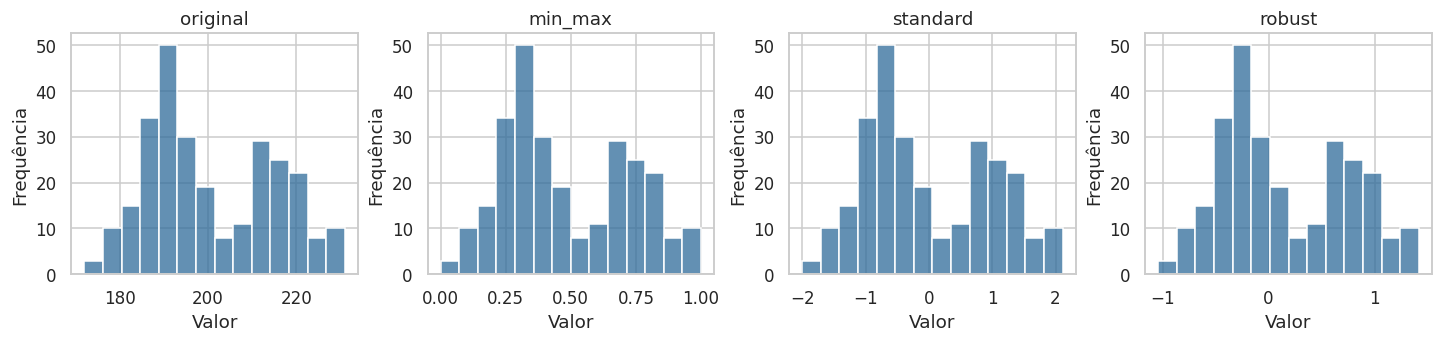

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3), constrained_layout=True)

for coluna, ax in zip(escalas.columns, axes):
    sns.histplot(escalas[coluna], bins=14, color="#2F6B9A", ax=ax)
    ax.set(title=coluna, xlabel="Valor", ylabel="Frequência")

plt.show()

*Figura — A mesma feature de treino após três transformações. A escala horizontal muda, mas o formato, a ordem das observações e eventuais valores extremos são preservados.*

## 6. Análise bivariada

A análise bivariada investiga a associação entre duas variáveis.

- **Scatterplot:** mostra forma, direção, agrupamentos e pontos influentes entre duas variáveis numéricas.
- **Pearson:** $r=\mathrm{cov}(X,Y)/(s_Xs_Y)$; resume associação **linear** e é sensível a extremos.
- **Spearman:** calcula a correlação sobre os postos; resume associação **monotônica**, mesmo quando não é linear.
- **Boxplot por categoria:** compara posição, dispersão e sobreposição de uma variável numérica entre grupos.

Correlação descreve associação; não demonstra causalidade.

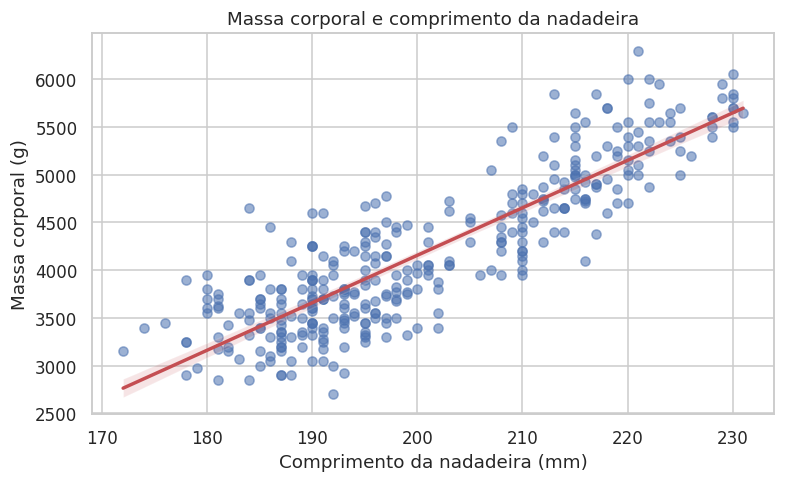

In [ ]:
fig, ax = plt.subplots()
sns.regplot(
    data=dados_modelo,
    x="comprimento_nadadeira_mm",
    y="massa_corporal_g",
    scatter_kws={"alpha": 0.55},
    line_kws={"color": "#C44E52"},
    ax=ax,
)
ax.set(
    title="Massa corporal e comprimento da nadadeira",
    xlabel="Comprimento da nadadeira (mm)",
    ylabel="Massa corporal (g)",
)
plt.show()

*Figura — Pinguins com nadadeiras mais longas tendem a apresentar maior massa corporal. A reta resume a tendência linear, mas os agrupamentos visíveis sugerem verificar também a espécie.*

In [ ]:
variaveis_correlacao = dados_modelo[[
    "comprimento_nadadeira_mm", "massa_corporal_g"
]]

correlacoes = pd.DataFrame({
    "coeficiente": ["Pearson", "Spearman"],
    "valor": [
        variaveis_correlacao.corr(method="pearson").iloc[0, 1],
        variaveis_correlacao.corr(method="spearman").iloc[0, 1],
    ],
})

correlacoes.round(3)

,coeficiente,valor
0,Pearson,0.871
1,Spearman,0.840


Os dois coeficientes indicam associação positiva forte. Pearson é um pouco maior porque a tendência global é próxima de linear; Spearman confirma que a relação também é monotônica. Esses números não explicam, sozinhos, diferenças entre espécies.

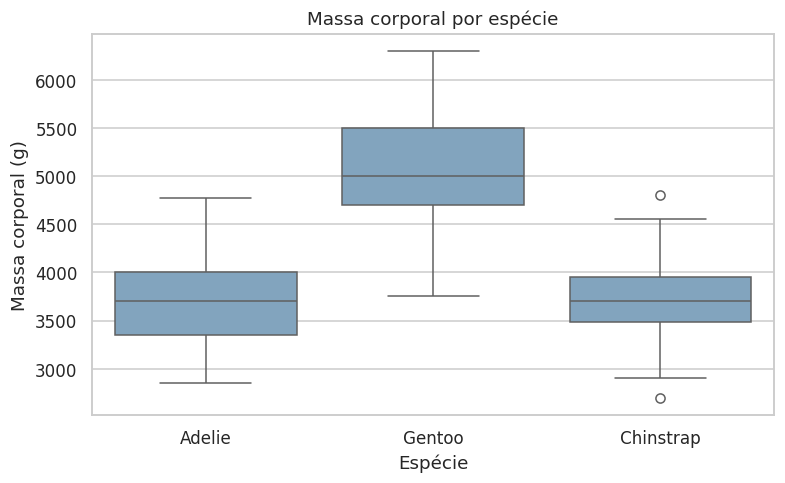

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(
    data=dados_modelo,
    x="especie",
    y="massa_corporal_g",
    color="#78A6C8",
    ax=ax,
)
ax.set(
    title="Massa corporal por espécie",
    xlabel="Espécie",
    ylabel="Massa corporal (g)",
)
plt.show()

*Figura — Distribuição da massa corporal por espécie. Gentoo apresenta valores centrais maiores, enquanto Adelie e Chinstrap têm forte sobreposição; o boxplot mostra diferenças de distribuição, não uma relação causal.*

## 7. Análise multivariada

A análise multivariada observa várias features simultaneamente. O **heatmap** resume correlações par a par; o **pairplot** acrescenta a forma das distribuições, relações não lineares e agrupamentos.

Muitas correlações não substituem uma hipótese de análise. Além disso, uma associação pode refletir grupos, como as espécies, e não uma relação direta entre as medidas.

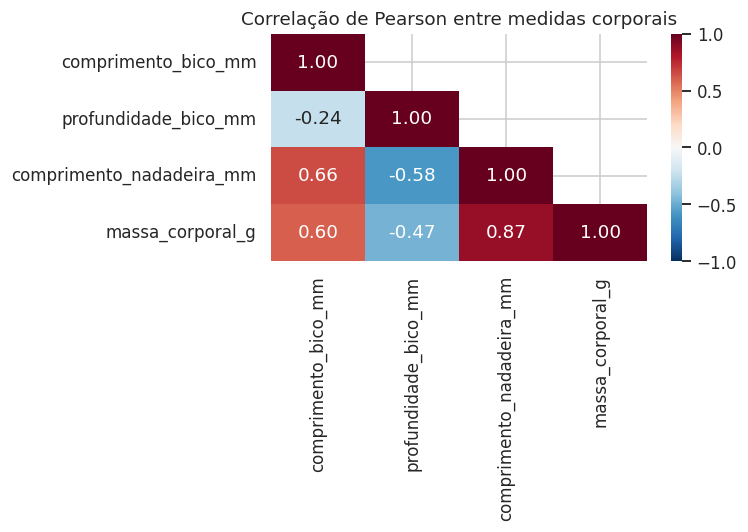

In [ ]:
import numpy as np

medidas = [
    "comprimento_bico_mm",
    "profundidade_bico_mm",
    "comprimento_nadadeira_mm",
    "massa_corporal_g",
]

corr = dados_modelo[medidas].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Correlação de Pearson entre medidas corporais")
plt.tight_layout()
plt.show()

*Figura — Matriz de correlação das quatro medidas. A massa corporal se associa fortemente ao comprimento da nadadeira; sinais e magnitudes podem mudar quando as espécies são analisadas separadamente.*

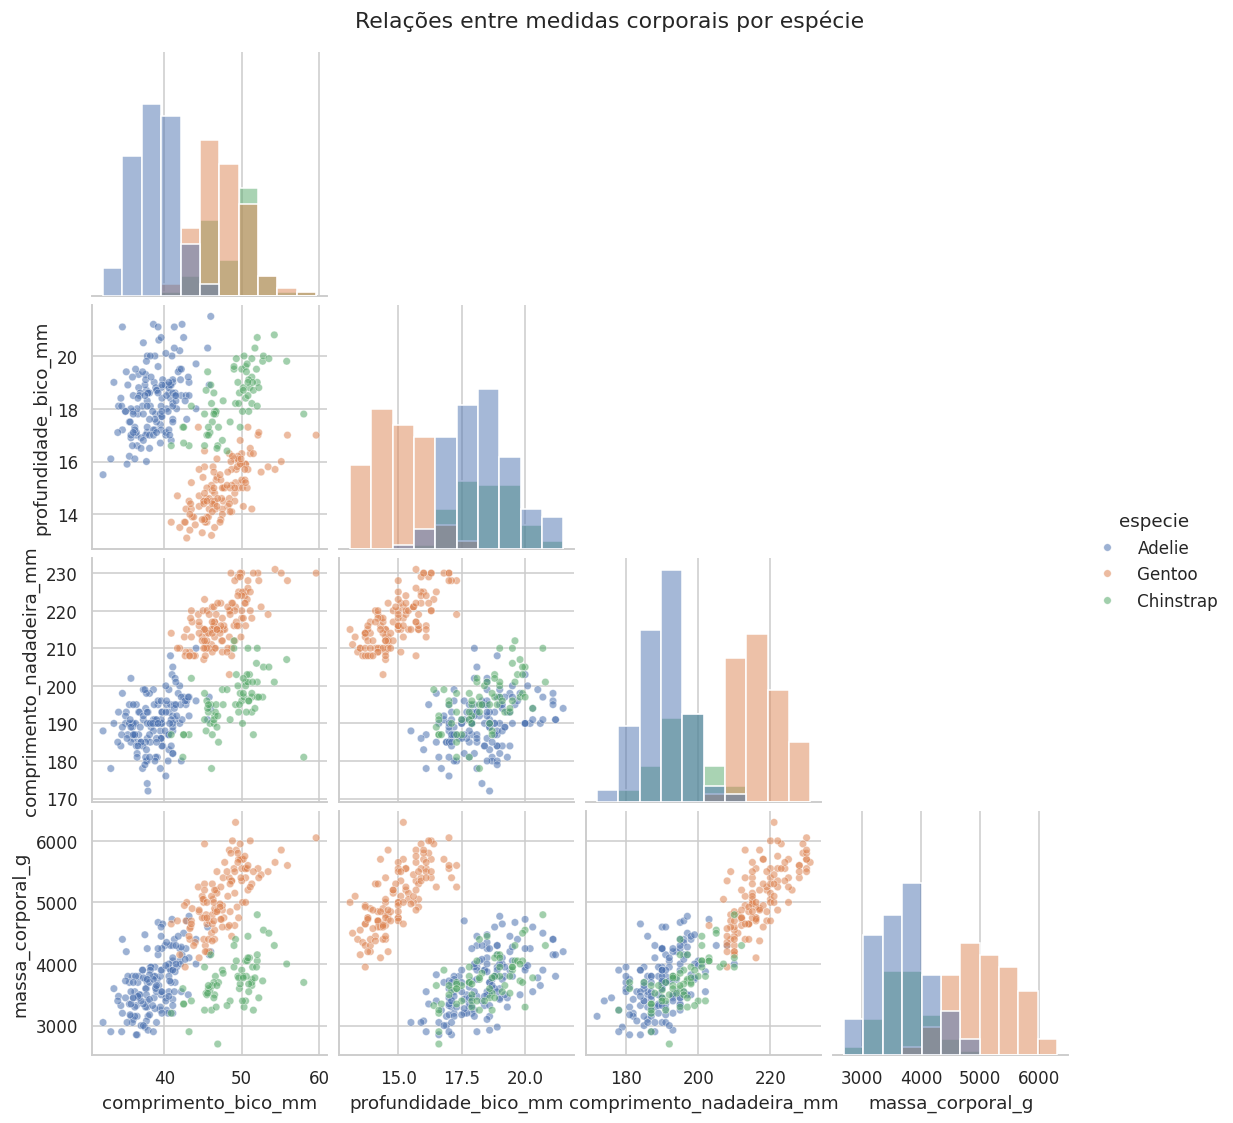

In [ ]:
grafico = sns.pairplot(
    dados_modelo[medidas + ["especie"]],
    hue="especie",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.55, "s": 24},
)
grafico.fig.suptitle("Relações entre medidas corporais por espécie", y=1.02)
plt.show()

*Figura — Distribuições e relações par a par, separadas por espécie. Os agrupamentos mostram por que uma correlação global pode combinar diferenças entre grupos e relações dentro de cada grupo.*

## 8. Fluxo final com `ColumnTransformer`

O `ColumnTransformer` aplica tratamentos diferentes por tipo de feature em um único objeto. O treino ajusta medianas, categorias e escalas; o teste apenas recebe as transformações já aprendidas. `ano` foi mantido como contexto e excluído do pré-processamento deste exemplo por `remainder="drop"`.

In [ ]:
pipeline_numerico = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="median")),
    ("padronizacao", StandardScaler()),
])

pipeline_categorico = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="constant", fill_value="não informado")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessador = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerico, features_numericas),
        ("categoricas", pipeline_categorico, features_categoricas),
    ],
    remainder="drop",
)

X_treino_pronto = preprocessador.fit_transform(X_treino)
X_teste_pronto = preprocessador.transform(X_teste)

pd.DataFrame({
    "conjunto": ["treino", "teste"],
    "linhas": [X_treino_pronto.shape[0], X_teste_pronto.shape[0]],
    "colunas_transformadas": [X_treino_pronto.shape[1], X_teste_pronto.shape[1]],
    "operacao": ["fit_transform", "transform"],
})

,conjunto,linhas,colunas_transformadas,operacao
0,treino,275,12,fit_transform
1,teste,69,12,transform


## Escolha do diagnóstico conforme feature e target

| Tipo da feature | Tipo do target | Diagnóstico inicial indicado | Exemplo |
|---|---|---|---|
| Numérica | Numérico | Scatterplot, Pearson e Spearman | Nadadeira × massa corporal |
| Categórica | Numérico | Resumo por grupo e boxplot | Espécie × massa corporal |
| Numérica | Categórico | Histogramas ou boxplots por classe | Medidas × espécie |
| Categórica | Categórico | Tabela de contingência e proporções | Ilha × espécie |

O diagnóstico depende do tipo das variáveis e da pergunta. Nenhum gráfico ou coeficiente isolado determina causalidade ou a qualidade de um modelo.

## Resumo

| Técnica | Problema que ajuda a resolver | Cuidado principal |
|---|---|---|
| Diagnóstico de tipos e ausências | Escolher tratamentos coerentes | Distinguir ausência de “não se aplica” |
| Remoção do alvo ausente | Manter casos avaliáveis | Fazer antes da divisão treino/teste |
| Imputação pela mediana | Preencher feature numérica | Aprender a mediana somente no treino |
| Categoria “não informado” | Preservar ausência categórica | Não confundir com uma categoria observada |
| One-Hot Encoding | Representar categorias nominais | Ignorar categorias novas sem criar ordem |
| `merge` validado | Combinar informações relacionadas | Verificar chaves e cardinalidade |
| IIQ e z-score | Sinalizar valores extremos | Investigar antes de remover |
| MinMax, Standard e Robust | Ajustar magnitudes das features | Scaling não remove extremos nem normaliza |
| Pearson e Spearman | Resumir associações numéricas | Associação não implica causalidade |
| Heatmap e pairplot | Explorar várias relações | Considerar grupos e redundância |
| `ColumnTransformer` | Reunir o pré-processamento | Ajustar no treino e transformar o teste |

### Exercícios

1. Compare Pearson e Spearman entre comprimento e profundidade do bico.
2. Repita a regra do IIQ para a massa corporal dentro de cada espécie.
3. Troque `StandardScaler` por `RobustScaler` no fluxo final e compare os valores transformados.